# Comparação entre dados Sintéticos (HDT) e Reais

Avalia a **human-likeness** dos Human Digital Twins comparando distribuições de resposta, estatísticas descritivas por dimensão do modelo 7S e equivalência estatística (Mann-Whitney U + Cohen's d).


Neste ponto avaliamos se a amostra sintética é suficientemente parecida com a humana.

Validamos se os HDTs eram parecidos o bastante com os humanos para entrar no PLS-SEM.

1. Testes de equivalência estatística (Mann-Whitney U + Cohen's d)

- O **Mann-Whitney** comparou as distribuições item a item;
  Para cada item avalia se as distribuições real e sintética são estatisticamente equivalentes.
  62,5% sem diferença indica boa sobreposição.

- O **Tamanho do Efeito (Cohen’s d)** mede a magnitude prática das diferenças; 81,2% com |d|<0,50 mostra diferenças pequenas. Ou seja, mostra se a diferença, mesmo existindo, é grande na prática; 81,2% foram pequenas.

2. Outros

- A **Diferença média Likert** mede a distância média entre notas; 0,146 é quase nula.

- A **Correlação de Spearman** mede se dois grupos ordenam as coisas de forma parecida.

  No contexto do artigo, ela não pergunta apenas:
  “Humanos e HDTs deram exatamente as mesmas notas?”
  Ela pergunta algo mais importante para o modelo:
  “Os itens que os humanos avaliaram como mais altos também foram avaliados como mais altos pelos HDTs? E os itens mais baixos também ficaram mais baixos?”

  Ou seja, Spearman avalia a semelhança no ranking das respostas. 0,8179 indica que ambos priorizaram fatores parecidos.\_


## 1. Carregamento dos dados


### Carregar Sintéticos e Reais


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import scipy.stats as stats

df_real = pd.read_csv("inputs/questionario_real_formatado.csv")
# df_sint = pd.read_csv("inputs/questionario_sintetico.csv")
df_sint = pd.read_csv("inputs/questionario_sintetico_1000.csv")

ITENS = [c for c in df_sint.columns if c not in ["Perfil", "sexo", "idade"]]

DIMENSOES = {
    "Shared Values": ["SV1", "SV2", "SV3", "SV4"],
    "Strategy": ["SG1", "SG2", "SG3", "SG4"],
    "Structure": ["SU1", "SU2", "SU3", "SU4"],
    "Systems": ["SM1", "SM2", "SM3", "SM4"],
    "Staff": ["SF1", "SF2", "SF3", "SF4"],
    "Style": ["SY1", "SY2", "SY3", "SY4"],
    "Skills": ["SK1", "SK2", "SK3", "SK4"],
    "Technology Protection": ["TP1", "TP2", "TP3", "TP4"],
}

print(
    f"Real: {df_real.shape[0]} respondentes | Sintético: {df_sint.shape[0]} respondentes"
)

Real: 46 respondentes | Sintético: 1000 respondentes


## 2. Estatísticas descritivas por dimensão


In [18]:
rows = []
for dim, itens in DIMENSOES.items():
    real_vals = df_real[itens].values.flatten().astype(float)
    sint_vals = df_sint[itens].values.flatten().astype(float)
    rows.append(
        {
            "Dimensão": dim,
            "Média Real": round(real_vals.mean(), 3),
            "DP Real": round(real_vals.std(), 3),
            "Média Sint": round(sint_vals.mean(), 3),
            "DP Sint": round(sint_vals.std(), 3),
            "Δ Média": round(sint_vals.mean() - real_vals.mean(), 3),
        }
    )

desc_df = pd.DataFrame(rows).set_index("Dimensão")
desc_df

,Média Real,DP Real,Média Sint,DP Sint,Δ Média
Dimensão,,,,,
Shared Values,5.804,1.389,5.938,0.787,0.133
Strategy,5.179,1.586,5.299,0.788,0.119
Structure,5.576,1.663,5.514,0.792,-0.063
Systems,4.853,1.971,4.601,1.625,-0.252
Staff,4.636,1.895,4.710,1.136,0.075
Style,5.424,1.679,NaN,NaN,NaN
Skills,4.989,1.754,4.687,0.976,-0.302
Technology Protection,4.810,1.827,4.580,0.687,-0.229


## 3. Testes de equivalência estatística (Mann-Whitney U + Cohen's d)

Para cada item avalia se as distribuições real e sintética são estatisticamente equivalentes.

- **p > 0,05** → sem diferença significativa (suporta human-likeness)
- **|d| < 0,20** → efeito negligenciável


In [19]:
def cohens_d(a, b):
    pooled_std = np.sqrt((a.std() ** 2 + b.std() ** 2) / 2)
    return (a.mean() - b.mean()) / pooled_std if pooled_std else 0.0


resultados = []
for item in ITENS:
    r = df_real[item].dropna().astype(float)
    s = df_sint[item].dropna().astype(float)
    U, p = stats.mannwhitneyu(r, s, alternative="two-sided")
    d = cohens_d(r, s)
    resultados.append(
        {
            "Item": item,
            "p-valor": round(p, 4),
            "Cohen's d": round(d, 3),
            "Sig. (p<0.05)": "Sim" if p < 0.05 else "Não",
            "Efeito": "negligenciável"
            if abs(d) < 0.2
            else ("pequeno" if abs(d) < 0.5 else "médio/grande"),
        }
    )

testes_df = pd.DataFrame(resultados).set_index("Item")
print(
    f"Itens SEM diferença significativa: {(testes_df['Sig. (p<0.05)'] == 'Não').sum()}/{len(ITENS)}"
)
print(
    f"Itens com efeito negligenciável:    {(testes_df['Efeito'] == 'negligenciável').sum()}/{len(ITENS)}"
)
testes_df

Itens SEM diferença significativa: 12/32
Itens com efeito negligenciável:    12/32


,p-valor,Cohen's d,Sig. (p<0.05),Efeito
Item,,,,
SV1,0.2759,-0.303,Não,pequeno
SV2,0.1062,-0.004,Não,negligenciável
SV3,0.0000,-0.963,Sim,médio/grande
SV4,0.0000,0.401,Sim,pequeno
SG1,0.2434,-0.018,Não,negligenciável
SG2,0.0011,-0.620,Sim,médio/grande
SG3,0.4075,-0.091,Não,negligenciável
SG4,0.0142,0.317,Sim,pequeno
SU1,0.3387,-0.190,Não,negligenciável


## 4. Distribuição de frequências Likert por dimensão (Human-Likeness)


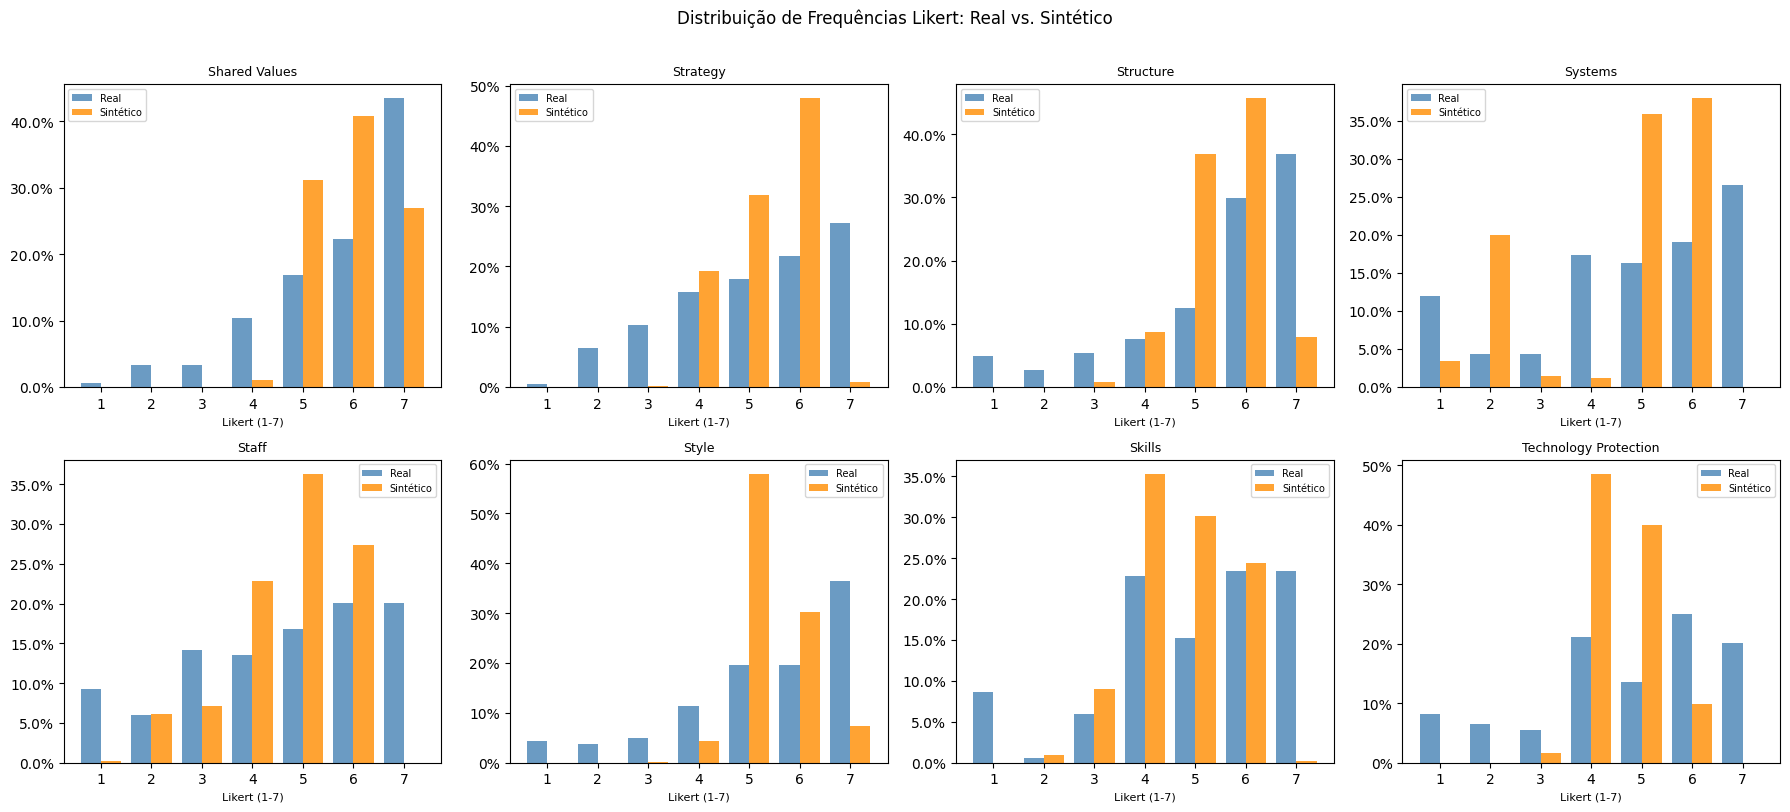

In [20]:
LIKERT = range(1, 8)
n_dims = len(DIMENSOES)
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
axes = axes.flatten()

for ax, (dim, itens) in zip(axes, DIMENSOES.items()):
    r_vals = df_real[itens].values.flatten().astype(float)
    s_vals = df_sint[itens].values.flatten().astype(float)

    r_freq = [np.mean(r_vals == v) * 100 for v in LIKERT]
    s_freq = [np.mean(s_vals == v) * 100 for v in LIKERT]

    x = np.arange(1, 8)
    ax.bar(x - 0.2, r_freq, width=0.4, label="Real", color="steelblue", alpha=0.8)
    ax.bar(x + 0.2, s_freq, width=0.4, label="Sintético", color="darkorange", alpha=0.8)
    ax.set_title(dim, fontsize=9)
    ax.set_xlabel("Likert (1-7)", fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(fontsize=7)

fig.suptitle(
    "Distribuição de Frequências Likert: Real vs. Sintético", fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig("outputs/comparacao_likert_distribuicao.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Médias por dimensão — Real vs. Sintético


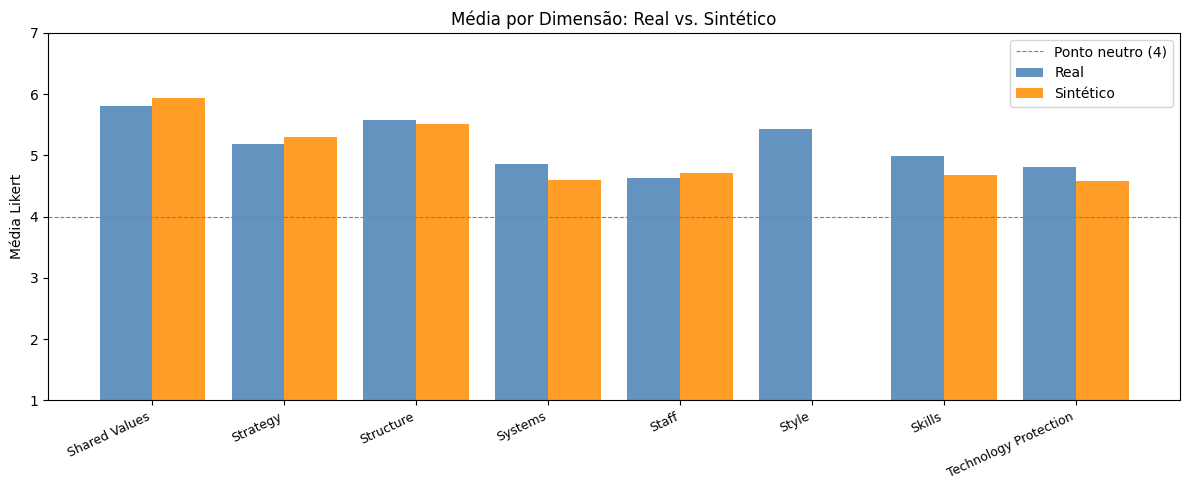

In [21]:
dims = list(DIMENSOES.keys())
medias_r = [df_real[v].values.flatten().mean() for v in DIMENSOES.values()]
medias_s = [df_sint[v].values.flatten().mean() for v in DIMENSOES.values()]

x = np.arange(len(dims))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.2, medias_r, 0.4, label="Real", color="steelblue", alpha=0.85)
ax.bar(x + 0.2, medias_s, 0.4, label="Sintético", color="darkorange", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(dims, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Média Likert")
ax.set_ylim(1, 7)
ax.axhline(4, ls="--", color="gray", lw=0.8, label="Ponto neutro (4)")
ax.legend()
ax.set_title("Média por Dimensão: Real vs. Sintético")
plt.tight_layout()
plt.savefig("outputs/comparacao_medias_dimensao.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Correlação de Spearman entre médias por item (human-likeness global)


Correlação de Spearman: ρ = 0.8048 (p = 0.0000)


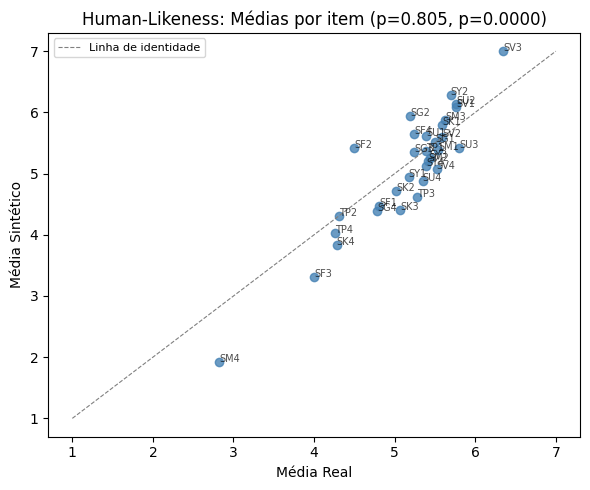

In [22]:
medias_itens_r = df_real[ITENS].mean()
medias_itens_s = df_sint[ITENS].mean()

rho, p_rho = stats.spearmanr(medias_itens_r, medias_itens_s)
print(f"Correlação de Spearman: ρ = {rho:.4f} (p = {p_rho:.4f})")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(medias_itens_r, medias_itens_s, color="steelblue", alpha=0.8)
for item in ITENS:
    ax.annotate(
        item, (medias_itens_r[item], medias_itens_s[item]), fontsize=7, alpha=0.7
    )
lim = [1, 7]
ax.plot(lim, lim, "--", color="gray", lw=0.8, label="Linha de identidade")
ax.set_xlabel("Média Real")
ax.set_ylabel("Média Sintético")
ax.set_title(f"Human-Likeness: Médias por item (p={rho:.3f}, p={p_rho:.4f})")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(
    "outputs/comparacao_human_likeness_scatter.png", dpi=150, bbox_inches="tight"
)
plt.show()

## 7. Resumo da avaliação de human-likeness


In [23]:
n_sem_sig = (testes_df["Sig. (p<0.05)"] == "Não").sum()
n_neglig = (testes_df["Cohen's d"].abs() < 0.50).sum()
delta_medio = desc_df["Δ Média"].abs().mean()

print("=== Resumo Human-Likeness ===")
print(
    f"Itens sem diferença significativa (p≥0.05): {n_sem_sig}/{len(ITENS)} ({100 * n_sem_sig / len(ITENS):.1f}%)"
)
print(
    f"Itens com |d| < 0,50:                        {n_neglig}/{len(ITENS)} ({100 * n_neglig / len(ITENS):.1f}%)"
)
print(f"Diferença absoluta média entre médias:       {delta_medio:.3f} pontos Likert")
print(f"Correlação de Spearman (médias por item):    p = {rho:.4f} (p = {p_rho:.4f})")

=== Resumo Human-Likeness ===
Itens sem diferença significativa (p≥0.05): 12/32 (37.5%)
Itens com |d| < 0,50:                        26/32 (81.2%)
Diferença absoluta média entre médias:       0.168 pontos Likert
Correlação de Spearman (médias por item):    p = 0.8048 (p = 0.0000)


## 8. Conclusão: aceitação da amostra sintética


In [24]:
# Critérios de aceitação
LIMIAR_P_SEM_SIG = 0.60  # ≥60% dos itens sem diferença significativa
LIMIAR_NEGLIG = 0.70  # ≥70% dos itens com |d| < 0,50
LIMIAR_DELTA = 0.50  # Δ médio < 0.50 pontos Likert
LIMIAR_RHO = 0.80  # Correlação de Spearman ≥ 0.80

perc_sem_sig = n_sem_sig / len(ITENS)
perc_neglig = n_neglig / len(ITENS)

criterios = {
    f"≥{LIMIAR_P_SEM_SIG:.0%} itens sem diferença significativa (p≥0.05)": perc_sem_sig
    >= LIMIAR_P_SEM_SIG,
    f"≥{LIMIAR_NEGLIG:.0%} itens com |d| < 0,50": perc_neglig >= LIMIAR_NEGLIG,
    f"Δ médio < {LIMIAR_DELTA} pontos Likert": delta_medio < LIMIAR_DELTA,
    f"Correlação de Spearman p ≥ {LIMIAR_RHO}": rho >= LIMIAR_RHO,  # type: ignore
}

n_aprovados = sum(criterios.values())
aceito = n_aprovados == len(criterios)

print("=== Critérios de Aceitação da Amostra Sintética ===")
for criterio, passou in criterios.items():
    simbolo = "✔" if passou else "✘"
    print(f"  {simbolo} {criterio}")

print()
if aceito:
    print(
        f"✅ AMOSTRA SINTÉTICA ACEITA ({n_aprovados}/{len(criterios)} critérios atendidos).\n"
        f"   Os Human Digital Twins apresentam human-likeness suficiente para uso\n"
        f"   como silicon sample na modelagem PLS-SEM do contexto brasileiro."
    )
else:
    print(
        f"❌ AMOSTRA SINTÉTICA REJEITADA ({n_aprovados}/{len(criterios)} critérios atendidos).\n"
        f"   Os padrões de resposta dos HDTs divergem dos respondentes reais\n"
        f"   além dos limiares aceitáveis. Recomenda-se revisar o prompting,\n"
        f"   o modelo LLM utilizado ou o tamanho da amostra sintética."
    )

=== Critérios de Aceitação da Amostra Sintética ===
  ✘ ≥60% itens sem diferença significativa (p≥0.05)
  ✔ ≥70% itens com |d| < 0,50
  ✔ Δ médio < 0.5 pontos Likert
  ✔ Correlação de Spearman p ≥ 0.8

❌ AMOSTRA SINTÉTICA REJEITADA (3/4 critérios atendidos).
   Os padrões de resposta dos HDTs divergem dos respondentes reais
   além dos limiares aceitáveis. Recomenda-se revisar o prompting,
   o modelo LLM utilizado ou o tamanho da amostra sintética.
